# active_sense demo: mouse info & water restriction log

This notebook shows how to connect to `at-database.stanford.edu`, create the `active_sense` tables, and insert baseline + daily records.

In [ ]:
import datajoint as dj

# --- fill in your credentials ---
dj.config['database.host'] = 'at-database.stanford.edu'
dj.config['database.user'] = 'root'
dj.config['database.password'] = 'xxxxx'

# optional: schema prefix, ssl params, etc., if your setup needs them
# dj.config['connection.init_function'] = lambda conn: conn.query('set session wait_timeout=28800')

dj.conn()
print('Connected to', dj.config['database.host'])


Connecting root@at-database.stanford.edu:3306
Connected to at-database.stanford.edu


In [2]:
import datajoint as dj
from pipeline import active_sense


Loading local settings from pipeline_config.json


In [3]:
print(active_sense.MouseInfo())
print(active_sense.DailyLog())

*animal_id    sex     dob     name     line     genotype     single_housing restriction_st baseline_weigh baseline_weigh notes    
+-----------+ +-----+ +-----+ +------+ +------+ +----------+ +------------+ +------------+ +------------+ +------------+ +-------+

 (Total: 0)

*animal_id    *log_date    phase     username     body_weight_g  weight_pct_bas weight_delta_f bottle_weight_ bottle_weight_ water_added_ml task     task_duration_ total_trials   correct_trials correct_rate   reward_size_ul task_water_ml  remain_water_m water_consumed target_water_m minimum_water_ removed_from_r health_status  notes    
+-----------+ +----------+ +-------+ +----------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +-------+

 (Total: 0)



In [2]:
import datajoint as dj
from pipeline import active_sense
# 1. Drop existing tables (Active Sense)
active_sense.DailyRestrictionLog.drop()
active_sense.MouseInfo.drop()
# 2. Re-create them by activating the schema
active_sense.schema.activate(create_tables=True)
# 3. Verify
print(active_sense.MouseInfo())
print(active_sense.DailyRestrictionLog())

Loading local settings from pipeline_config.json
`active_sense`.`daily_restriction_log` (0 tuples)
Tables dropped.  Restart kernel.
`active_sense`.`mouse_info` (1 tuples)
Tables dropped.  Restart kernel.


AttributeError: 'Schema' object has no attribute 'activate'

In [2]:
# ensure repo is on sys.path if pipeline isn't installed
import sys, pathlib
candidates = [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
pkg_dir = None
for c in candidates:
    candidate = c / 'python'
    if (candidate / 'pipeline').exists():
        pkg_dir = candidate
        break
if pkg_dir:
    if str(pkg_dir) not in sys.path:
        sys.path.insert(0, str(pkg_dir))
        print('Added to sys.path:', pkg_dir)
else:
    print('Could not find pipeline package; set PYTHONPATH or pip install -e .')


In [3]:
from pipeline.active_sense import DailyRestrictionLog

# 1. Drop the existing table (you will be prompted to confirm)
DailyRestrictionLog.drop()

# 2. To recreate it, simply reload the module or re-instantiate the table
# The simplest way in a fresh session is to just import it again,
# but since it's already imported, you can trigger creation by accessing it:
DailyRestrictionLog()

Loading local settings from pipeline_config.json
`active_sense`.`daily_restriction_log` (1 tuples)
Tables dropped.  Restart kernel.


DataJointError: The table `active_sense`.`daily_restriction_log` is not defined.

DataJointError: The table `active_sense`.`daily_restriction_log` is not defined.

In [2]:
# importing triggers table creation because create_tables=True in active_sense.py
from pipeline import active_sense, mice, experiment

# check the definitions
print(active_sense.MouseInfo())
print(active_sense.DailyRestrictionLog())


Loading local settings from pipeline_config.json
*animal_id    sex     dob     line     genotype     single_housing restriction_st baseline_weigh baseline_weigh notes    
+-----------+ +-----+ +-----+ +------+ +----------+ +------------+ +------------+ +------------+ +------------+ +-------+

 (Total: 0)

*animal_id    *log_date    phase     username     body_weight_g  weight_pct_bas weight_delta_f bottle_weight_ bottle_weight_ water_added_ml supplemental_w water_consumed target_water_m minimum_water_ removed_from_r health_status  notes    
+-----------+ +----------+ +-------+ +----------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +-------+

 (Total: 0)



## Schema Diagram
Visualizing the relationship between tables.

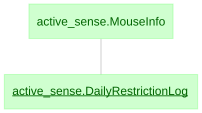

In [3]:
dj.ERD(active_sense)

## Insert baseline metadata
Replace the values below with real mouse IDs and baseline info before running.

In [ ]:
baseline = dict(
    animal_id=12345,  # existing mice.Mice primary key
    sex='F',
    dob='2024-04-01',
    line='Thy1-GCaMP6',
    genotype='Thy1-GCaMP6s',
    cohort='CohortA',
    source='Jackson',
    single_housing_date='2024-07-01',
    restriction_start_date='2024-07-04',
    restriction_target_days=30,
    baseline_weight_g=22.350,
    baseline_weight_date='2024-07-02',
    drinko_bottle_id='Bottle-01',
    notes='Baseline measured after single housing day 2.'
)
active_sense.MouseInfo.insert1(baseline, skip_duplicates=True)
active_sense.MouseInfo() & baseline


## Insert a daily log
Compute water intake from bottle weights or enter directly in `water_intake_ml`.
`weight_delta_from_baseline_g` = current - baseline; negative means loss.

In [5]:
log_entry = active_sense.DailyRestrictionLog.compute_daily_log(
    animal_id=12345,
    log_date='2024-07-05',
    body_weight_g=21.600,
    bottle_weight_before_g=50.000,
    bottle_weight_after_g=70.000,
    water_added_ml=20.000,
    supplemental_water_ml=0,
    username='atlab',
    health_status='BCS 3, bright/alert',
    notes='No spillage observed.'
)
active_sense.DailyRestrictionLog.insert1(log_entry, skip_duplicates=True)
key = {k: v for k, v in log_entry.items() if k in ['animal_id', 'log_date']}
active_sense.DailyRestrictionLog() & key


animal_id id number,log_date date of measurement,phase,username lab member,body_weight_g mouse weight (g),weight_pct_baseline percent of baseline body weight,weight_delta_from_baseline_g weight change vs baseline (current - baseline),bottle_weight_before_g Drinko bottle weight before adding water (retrieval weight),bottle_weight_after_g Drinko bottle weight after adding water (refill weight),"water_added_ml amount of water added (ml), including dish deliveries",supplemental_water_ml extra water given (e.g. syringe/gavage),water_consumed_ml calculated intake (bottle delta + supplemental),target_water_ml allowance based on baseline weight * 50 ml/kg,minimum_water_ml minimum allowance based on 25 ml/kg rule,removed_from_restriction mark if mouse taken off restriction today,health_status brief health observation (BCS/grooming/behavior),"notes free-text notes (spillage, handling, etc.)"
12345,2024-07-05,water_restriction,atlab,21.600,96.64,-0.750,50.000,70.000,20.000,0.000,None,1.118,0.559,0,"BCS 3, bright/alert",No spillage observed.


## Pipeline Context
Visualizing `active_sense` in the context of the core pipeline (`mice` and `experiment`).

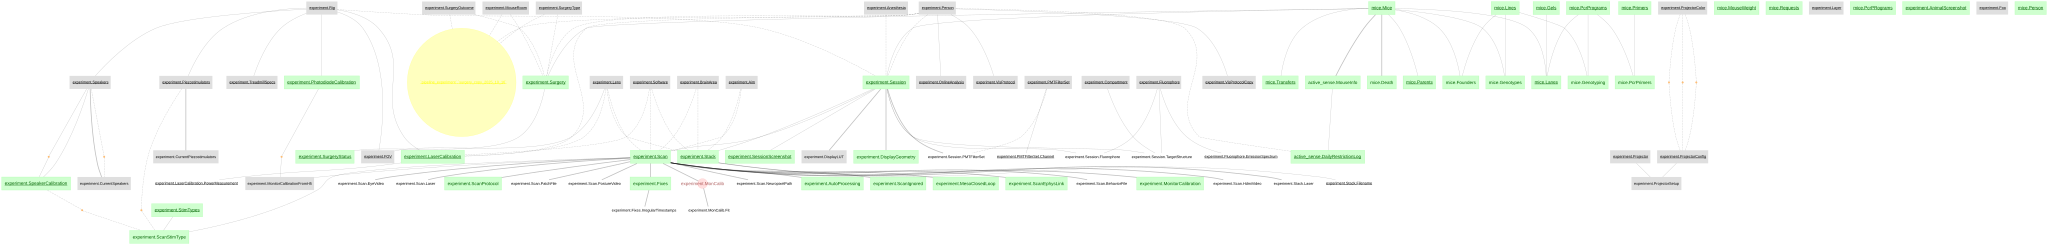

In [6]:
(dj.ERD(mice) + dj.ERD(experiment) + dj.ERD(active_sense))